In [1]:
import numpy as np
import torch
torch.set_default_dtype(torch.double)

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
alpha_prior, beta_prior = 1.0, 1.0
n, y = 5, 3
alpha_post = alpha_prior + y
beta_post  = beta_prior  + (n - y)

In [3]:
def log_beta_pdf(theta, a, b):
    logB = torch.lgamma(torch.tensor(a)) + torch.lgamma(torch.tensor(b)) - torch.lgamma(torch.tensor(a+b))
    return (a-1.0)*torch.log(theta) + (b-1.0)*torch.log(1 - theta) - logB

def log_normal_pdf(z, m, s):
    return -0.5*torch.log(2*np.pi*s*s) - 0.5*((z - m)/s)**2

def sigmoid(x): return torch.sigmoid(x)

# One-step ELBO estimator with reparameterization
def elbo_estimate(m, log_s, a, b, num_samples=2048):
    s = torch.exp(log_s)
    eps = torch.randn(num_samples, dtype=m.dtype, device=m.device)
    z   = m + s*eps
    theta = sigmoid(z)
    theta = torch.clamp(theta, 1e-12, 1-1e-12)

    lp = log_beta_pdf(theta, a, b)
    lq_z = log_normal_pdf(z, m, s)
    log_jac = - (torch.log(theta) + torch.log(1 - theta))
    lq_theta = lq_z + log_jac

    return (lp - lq_theta).mean()

# KL Monte Carlo helper
def kl_logistic_normal_vs_beta(m_val, s_val, a, b, n_samples=200_000):
    with torch.no_grad():
        z = torch.randn(n_samples, dtype=torch.float64)*s_val + m_val
        theta = torch.sigmoid(z)
        theta = torch.clamp(theta, 1e-12, 1 - 1e-12)
        lq = log_normal_pdf(z, torch.tensor(m_val), torch.tensor(s_val)) - (torch.log(theta) + torch.log(1 - theta))
        lp = log_beta_pdf(theta, a, b)
        return (lq - lp).mean().item()

# Logistic-Normal density
def logistic_normal_pdf(theta_grid, m_val, s_val):
    th = np.clip(theta_grid, 1e-12, 1-1e-12)
    z  = np.log(th) - np.log(1 - th)
    norm_logpdf = -0.5*np.log(2*np.pi*s_val*s_val) - 0.5*((z - m_val)/s_val)**2
    log_pdf = norm_logpdf - np.log(th) - np.log(1 - th)
    return np.exp(log_pdf)

In [4]:
# ----- Optimize -----
m     = torch.tensor(-2.0, requires_grad=True)   # bad init
log_s = torch.tensor(np.log(1.0), requires_grad=True)
optimizer = torch.optim.Adam([m, log_s], lr=0.05)

num_steps = 2000
snap_iters = {0, 25, 50}
snapshots = []   # (step, m, s, elbo, kl, grad_m, grad_s)

for t in range(num_steps):
    optimizer.zero_grad()
    loss = -elbo_estimate(m, log_s, alpha_post, beta_post, num_samples=4096)
    loss.backward()
    optimizer.step()

    if t in snap_iters:
        with torch.no_grad():
            s_val = torch.exp(log_s).item()
            m_val = m.item()
            elbo  = -loss.item()
            kl    = kl_logistic_normal_vs_beta(m_val, s_val, alpha_post, beta_post, n_samples=50_000)
        # store gradients before zeroing
        grad_m = m.grad.item()
        grad_s = log_s.grad.item() * s_val  # chain rule: grad wrt sigma instead of log sigma
        snapshots.append((t, m_val, s_val, elbo, kl, grad_m, grad_s))

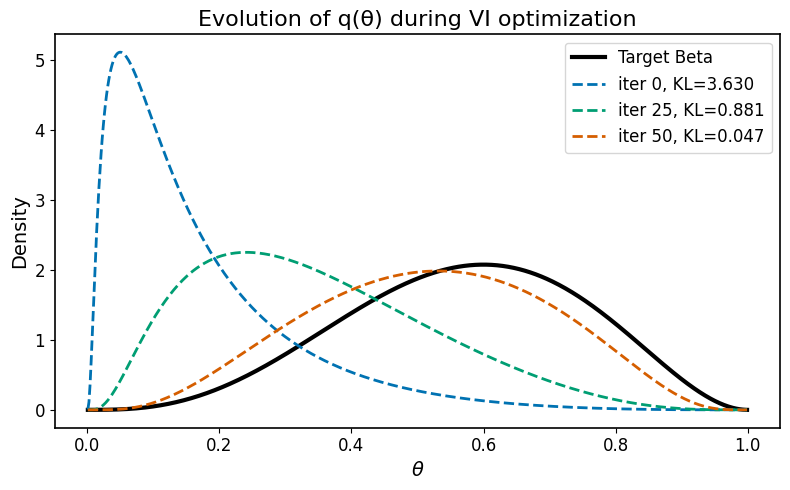

In [5]:
# ----- Plot densities evolution -----
theta_grid = np.linspace(0.001, 0.999, 600)
beta_pdf = np.exp(log_beta_pdf(torch.tensor(theta_grid), alpha_post, beta_post).numpy())

plt.figure(figsize=(8,5))
plt.plot(theta_grid, beta_pdf, lw=3, label="Target Beta", color="k")

for step, m_val, s_val, elbo, kl, grad_m, grad_s in snapshots:
    q_pdf = logistic_normal_pdf(theta_grid, m_val, s_val)
    plt.plot(theta_grid, q_pdf, lw=2, linestyle="--", label=f"iter {step}, KL={kl:.3f}")
plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.title("Evolution of q(θ) during VI optimization")
plt.legend()
plt.tight_layout()
plt.show()

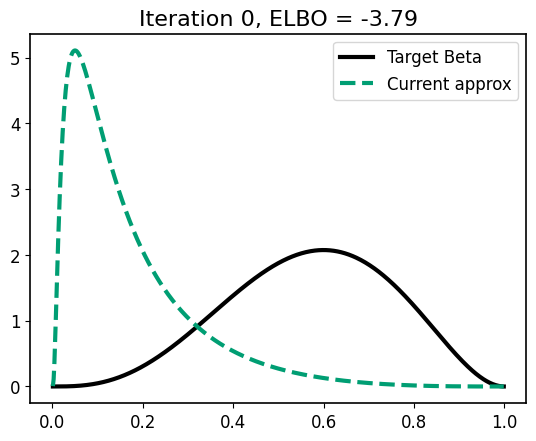

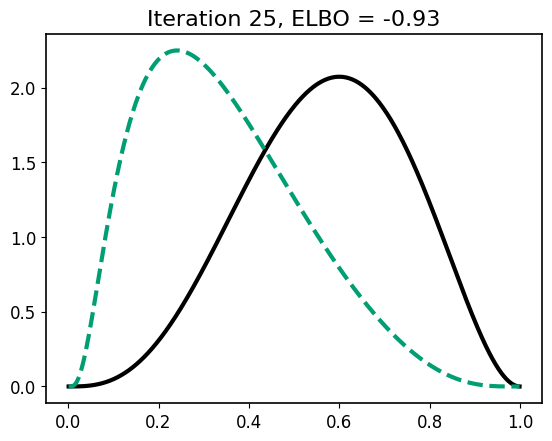

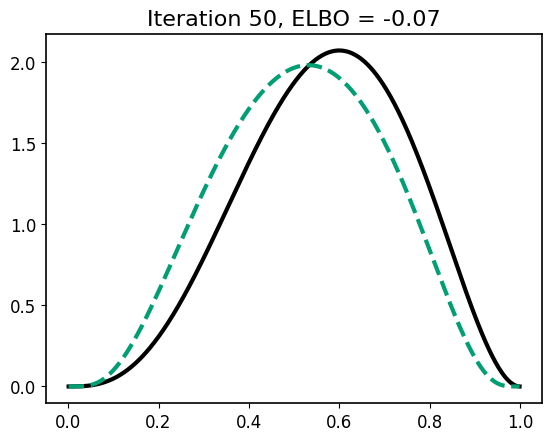

In [6]:
legend = True
for step, m_val, s_val, elbo, kl, grad_m, grad_s in snapshots:
    plt.plot(theta_grid, beta_pdf, lw=3, label="Target Beta", color="k")
    q_pdf = logistic_normal_pdf(theta_grid, m_val, s_val)
    plt.plot(theta_grid, q_pdf, lw=3, linestyle="--", c="C1", label="Current approx")

    if legend:
        plt.legend()
        legend = False

    plt.title(f"Iteration {step}, ELBO = {elbo:.2f}")

    plt.show()

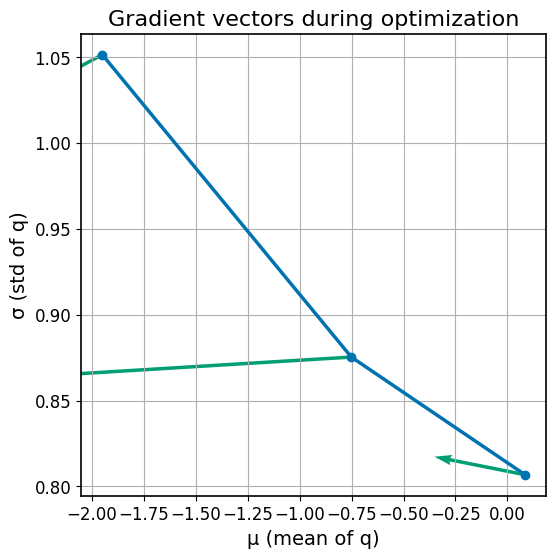

In [8]:
steps = [s[0] for s in snapshots]
mu_vals = [s[1] for s in snapshots]
sig_vals = [s[2] for s in snapshots]
grad_mus = [s[5] for s in snapshots]
grad_sigs= [s[6] for s in snapshots]

plt.figure(figsize=(6,6))
plt.quiver(mu_vals, sig_vals, grad_mus, grad_sigs, angles='xy', scale_units='xy', scale=1, color="C1")
plt.plot(mu_vals, sig_vals, marker="o", color="C0")
plt.xlabel("μ (mean of q)")
plt.ylabel("σ (std of q)")
plt.title("Gradient vectors during optimization")
plt.grid(True)
plt.show()